In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt


### Diabetes Prediction

In [115]:
data = load_diabetes(as_frame=True,scaled=False)
from sklearn.preprocessing import StandardScaler

scal = StandardScaler()

x = pd.DataFrame(scal.fit_transform(data.data),columns=data.feature_names)
y = data.target

df = pd.concat([x,y],axis=1)
df.rename({0:'target'},inplace = True)

print(df.head(20))

             age       sex       bmi        bp        s1        s2        s3  \
target  0.800500  1.065488  1.297088  0.459841 -0.929746 -0.732065 -0.912451   
1      -0.039567 -0.938537 -1.082180 -0.553505 -0.177624 -0.402886  1.564414   
2       1.793307  1.065488  0.934533 -0.119214 -0.958674 -0.718897 -0.680245   
3      -1.872441 -0.938537 -0.243771 -0.770650  0.256292  0.525397 -0.757647   
4       0.113172 -0.938537 -0.764944  0.459841  0.082726  0.327890  0.171178   
5      -1.948811 -0.938537 -0.855583 -0.408741 -1.450445 -1.666931  0.867796   
6      -0.956004  1.065488 -0.991541 -0.336359 -0.842963 -0.521390  0.016374   
7       1.335088  1.065488 -0.039834  1.400804  1.905174  2.289794  0.480786   
8       0.876870  1.065488  1.297088 -0.843032 -0.293335  0.130383 -0.602843   
9      -1.490592 -0.938537  0.821235 -0.698268 -0.264408 -0.725481 -0.525441   
10     -2.025181 -0.938537 -1.761971  0.170313 -2.173639 -1.903940 -0.293235   
11      0.571391  1.065488  0.368041 -0.

#Features
#data.columns = ['Age','Sex','Bmi','Bp','Tc','Ldl','Hdl','Tch','Ltg','Glu']
#bmi:body mass index,bp:average blood pleasure,tc:total cherun cholesterol
#ldl:low-density liproteins,hdl:high-density liproteins,tch:total cholesterol
#lgt:possibly log of serum triglycerides level,glu:blood sugar level


## Clean and Eda

In [116]:
df.describe(),df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 442 entries, target to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 41.4+ KB


(                age           sex           bmi            bp            s1  \
 count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
 mean   8.037814e-18  1.607563e-16  1.004727e-16  1.060991e-15 -2.893613e-16   
 std    1.001133e+00  1.001133e+00  1.001133e+00  1.001133e+00  1.001133e+00   
 min   -2.254290e+00 -9.385367e-01 -1.897929e+00 -2.363050e+00 -2.665411e+00   
 25%   -7.841722e-01 -9.385367e-01 -7.196249e-01 -7.706500e-01 -7.200196e-01   
 50%    1.131724e-01 -9.385367e-01 -1.531324e-01 -1.192138e-01 -9.084100e-02   
 75%    8.005001e-01  1.065488e+00  6.569519e-01  7.493678e-01  5.961931e-01   
 max    2.327895e+00  1.065488e+00  3.585718e+00  2.776058e+00  3.235851e+00   
 
                  s2            s3            s4            s5            s6  \
 count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
 mean  -1.245861e-16 -1.326239e-16 -1.446806e-16  2.250588e-16  2.371155e-16   
 std    1.001133e+00  1.001133e+00  1.

- In a problem like this,we want to see how variables can affect others and what their weights or importances in that processes.in our case,we want to predict diabetes develop according patient caracteristics.

for discover it,let's look at variables relations first.

<Axes: >

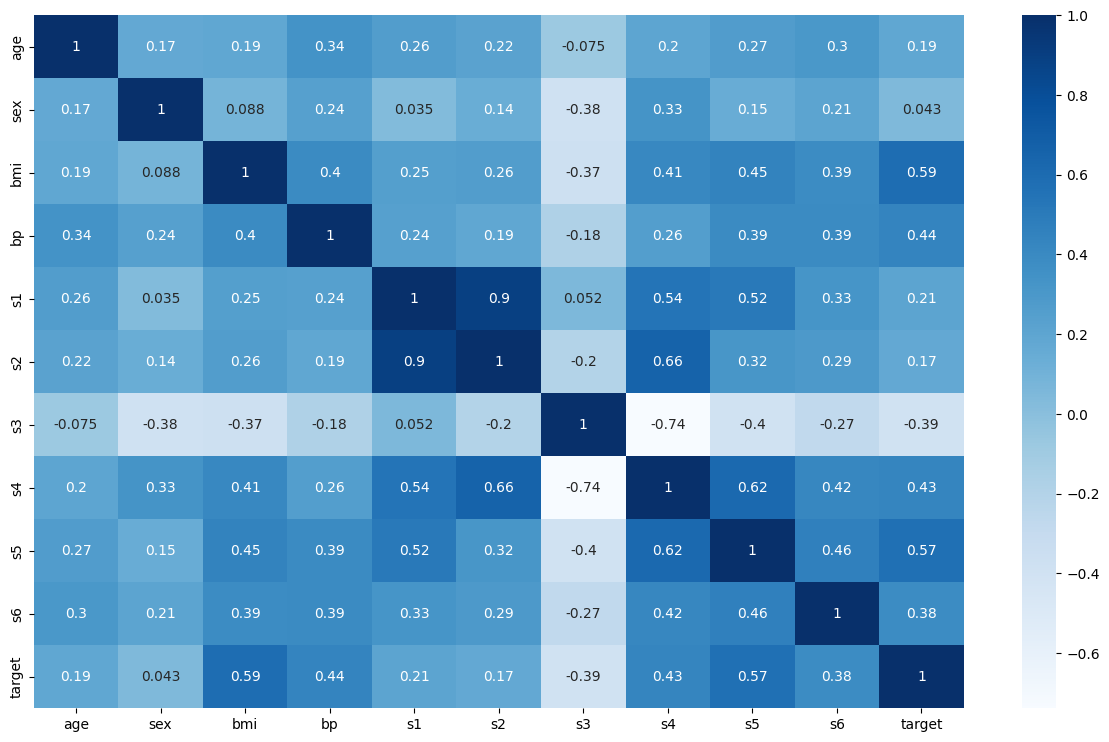

In [117]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(),cmap='Blues',annot=True)

In [118]:
df.corr()['target'].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

This means that __body mass index__ and __Triglicerydes__ are most correlationed with diabetes progression.

Let's create ranges category with pd.cut for *bmi* and *s5* and see diabetes progression for each class:

In [119]:
bmi_1 = [min(df['bmi']),  df['bmi'].quantile(0.15),df['bmi'].quantile(0.5),df['bmi'].quantile(0.85) , max(df['bmi'])]
s5_1 = [min(df['s5']) , df['s5'].quantile(0.15),df['s5'].quantile(0.5),df['s5'].quantile(0.85), max(df['s5'])]


df['bmi_cat'] = pd.cut(df['bmi'],bins = bmi_1,
labels = ['min_bmi','low_bmi','medium_bmi','high_bmi'])

df['s5_cat'] = pd.cut(df['s5'],bins = s5_1,
labels = ['min_s5','low_s5','medium_s5','high_s5'])

In [120]:
print(df[df['bmi_cat']=='high_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='medium_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='min_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='low_bmi']['bmi'].mean())

1.7083963722780422
0.4154335518167404
-1.3371863546831104
-0.5472650246837141


In [121]:
df.head(30)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,bmi_cat,s5_cat
target,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989,151.0,high_bmi,medium_s5
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479,75.0,min_bmi,min_s5
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154,141.0,medium_bmi,medium_s5
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823,206.0,low_bmi,medium_s5
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568,135.0,low_bmi,low_s5
5,-1.948811,-0.938537,-0.855583,-0.408741,-1.450445,-1.666931,0.867796,-1.606102,-0.865679,-2.025562,97.0,low_bmi,low_s5
6,-0.956004,1.065488,-0.991541,-0.336359,-0.842963,-0.521390,0.016374,-0.830301,-1.322752,-0.806403,138.0,min_bmi,min_s5
7,1.335088,1.065488,-0.039834,1.400804,1.905174,2.289794,0.480786,0.372192,-0.752992,0.064426,63.0,medium_bmi,low_s5
8,0.876870,1.065488,1.297088,-0.843032,-0.293335,0.130383,-0.602843,-0.054499,-0.314510,0.238591,110.0,high_bmi,low_s5
9,-1.490592,-0.938537,0.821235,-0.698268,-0.264408,-0.725481,-0.525441,-0.054499,1.424090,-0.283906,310.0,medium_bmi,high_s5


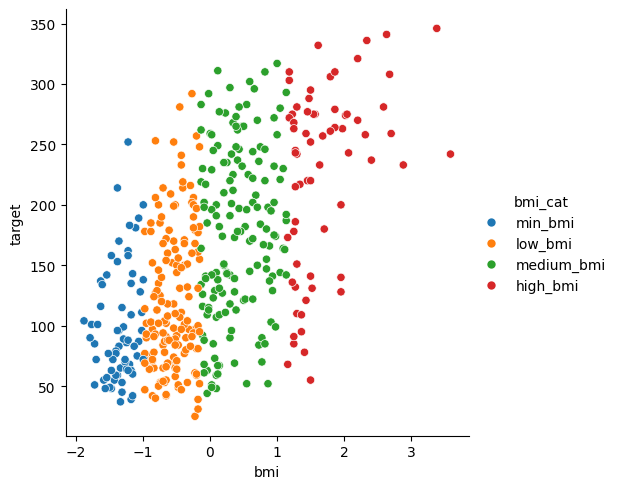

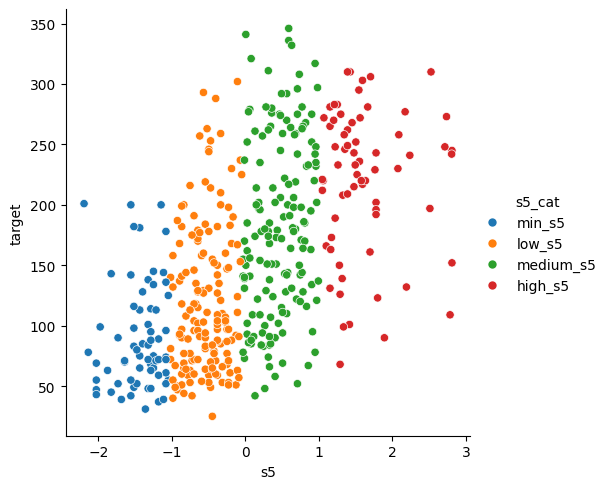

In [122]:
sns.relplot(data=df,x='bmi',y='target',hue='bmi_cat',kind='scatter')
sns.relplot(data=df,x='s5',y='target',hue='s5_cat',kind='scatter')

- So as you see,the level of **s5** and **bmi** don't change sick progression.

In previous heatmap,we've seem that **s4** and **sex** are correlated with **s5** and **bmi**,what can be tested too:


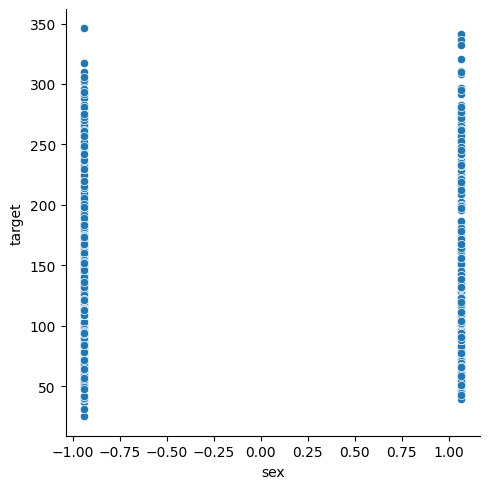

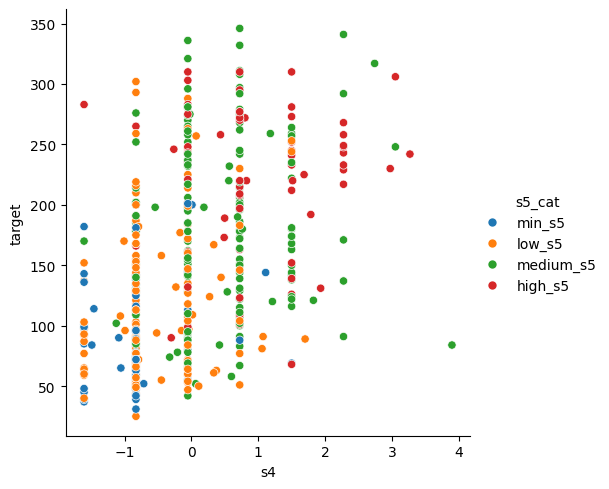

In [123]:
sns.relplot(data=df,x='sex',y='target',kind='scatter')
sns.relplot(data=df,x='s4',y='target',hue='s5_cat',kind='scatter')

- After see relations between indicators,let's compare his counts :


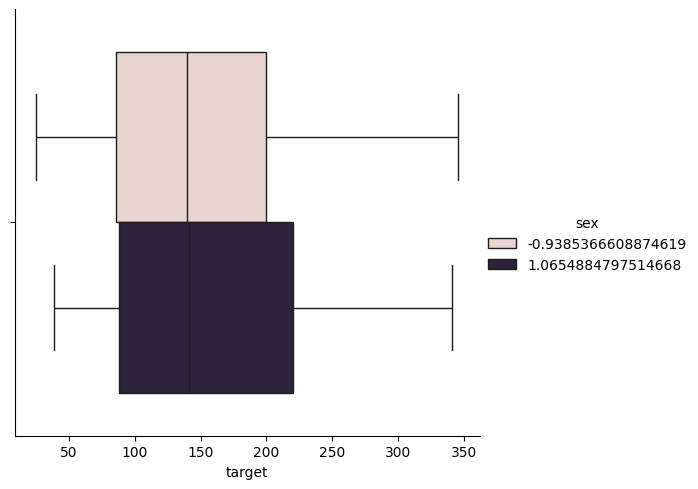

In [124]:
sns.catplot(data=df,x='target',hue='sex',kind='box')

<Axes: xlabel='target', ylabel='Density'>

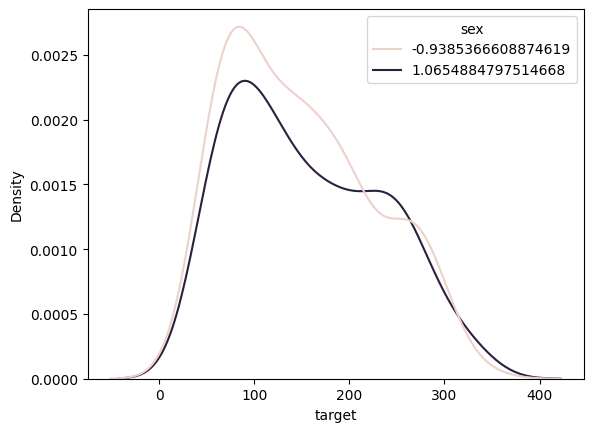

In [125]:
sns.kdeplot(data=df,x='target',hue='sex')

<Axes: xlabel='age', ylabel='target'>

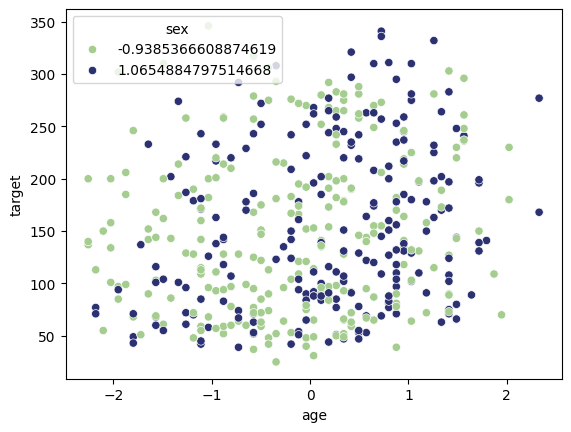

In [126]:
sns.scatterplot(data=df,x='age',y='target',hue='sex',palette='crest')

<Figure size 2000x900 with 0 Axes>

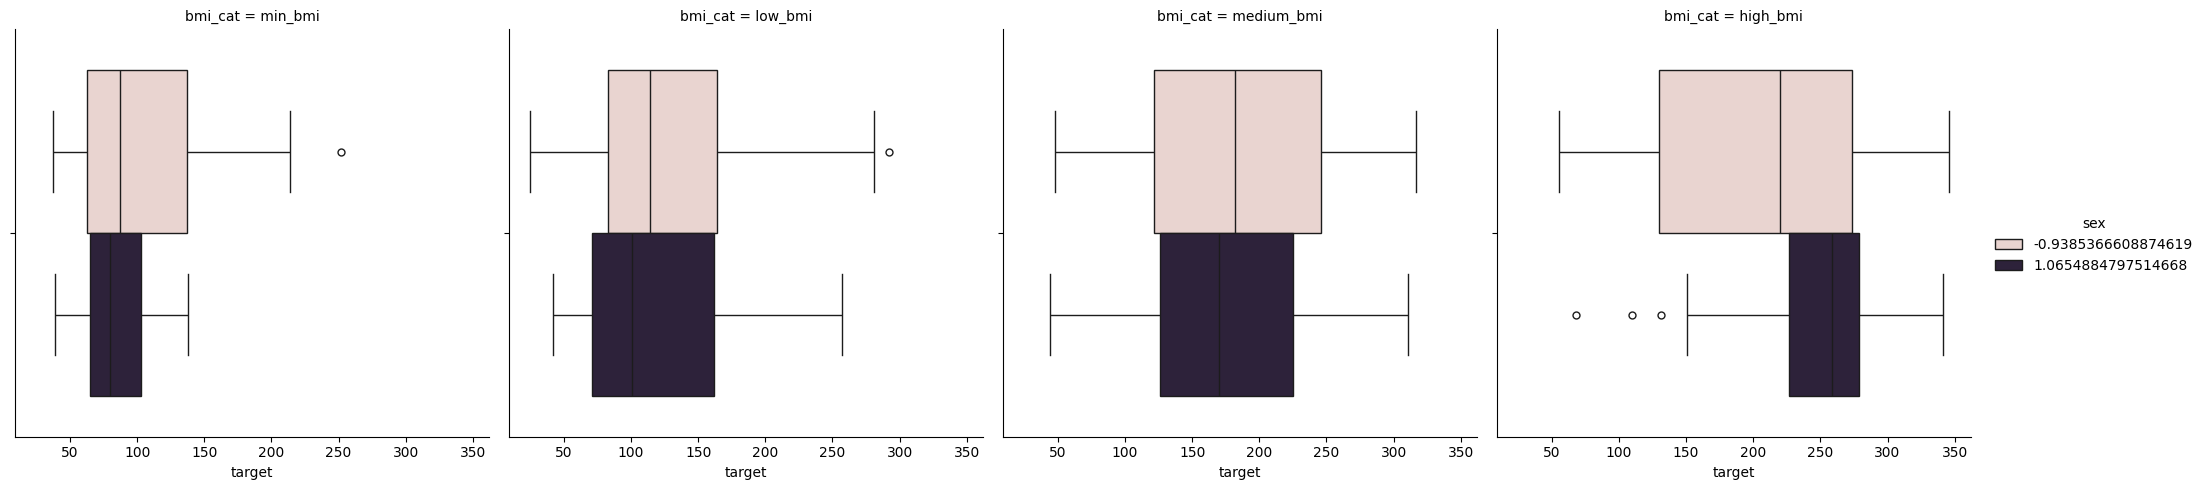

In [127]:
plt.figure(figsize=(20,9))
sns.catplot(data=df,x='target',kind='box',hue='sex',col='bmi_cat')

<Axes: xlabel='age', ylabel='bmi'>

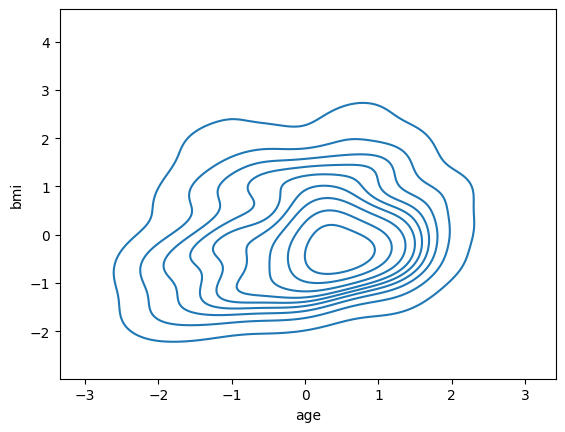

In [128]:
sns.kdeplot(data=df,x='age',y='bmi')

## Stats and Hipotesis Testing
- For a more precise view,we will calculate variables stats and compare them to get insights.this calculations are based on hipotesis that we've created after visualizing data.

#### Questions:

- 1. Bmi levels affects diabetes progression?

- 2. Bmi + Bp are determinants together for diabetes progression?

- 3. Are old people the most heavy?

- 4. Age + Sex affects diabetes progression?

- 5. Blood sugar level and Colesterol affects diabetes?

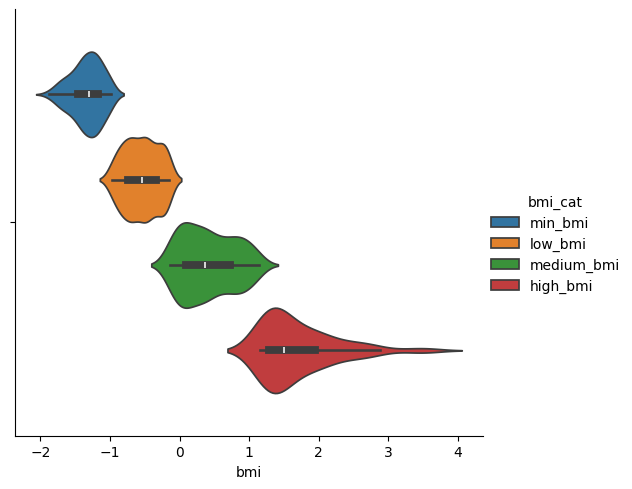

In [129]:
#1: using bmi group means:
bmi_high = df[df['bmi_cat']=='high_bmi']['target']
bmi_medium = df[df['bmi_cat']=='medium_bmi']['target']
bmi_min = df[df['bmi_cat']=='min_bmi']['target']
bmi_low = df[df['bmi_cat']=='low_bmi']['target']

sns.catplot(data=df,x='bmi',hue='bmi_cat',kind ='violin')

- h0 = Bmi not affects diabetes progression ( high_bmi target = low_bmi target)
- h1 = Bmi affects diabetes progression ( high_bmi target > low_bmi target)

In [130]:
from scipy.stats import ttest_ind,f_oneway

max_min_bmi_test = ttest_ind(bmi_low,bmi_high)
print(max_min_bmi_test)

TtestResult(statistic=np.float64(-11.188632636695216), pvalue=np.float64(2.800997028358101e-23), df=np.float64(219.0))


bmi groups have a significant diference and is correlacted with target

In [131]:
#groups :

bmi_range_test = f_oneway(bmi_min,bmi_low,bmi_medium,bmi_high)
print(bmi_range_test)


F_onewayResult(statistic=np.float64(64.28704826559168), pvalue=np.float64(1.898238184713057e-34))


### Permutation Test

In [132]:
diff_observed = bmi_high.mean() - bmi_low.mean()

#group data
group_combined = np.concatenate([bmi_high,bmi_low])

diffs = [] # for plot distribuition

for i in range (10000):

    np.random.shuffle(group_combined)
    high = group_combined[:len(bmi_high)]
    low = group_combined[len(bmi_low):]

    diffs.append(high.mean() - low.mean())

p_value = np.mean(np.array(diffs) >= diff_observed)

p-val :  0.0


Text(0.5, 1.0, 'Null distribuition')

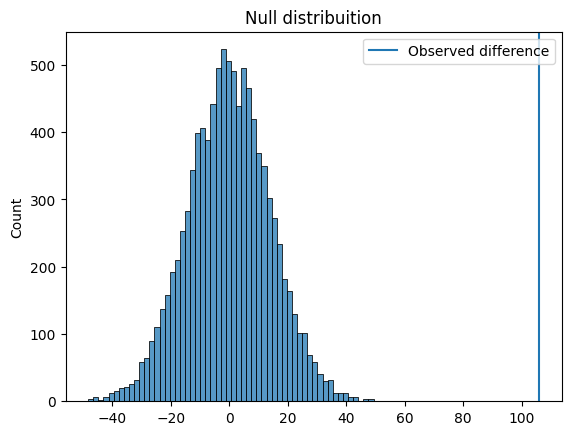

In [133]:
print(f'p-val :  {p_value}')

sns.histplot(x=diffs)
plt.axvline(x=diff_observed,label="Observed difference")
plt.legend()
plt.title('Null distribuition')

Observed difference automatically rejects h0 : high_bmi target =~ low_bmi target

2. Bmi + Bp
- h0 = bmi_bp not affects target
- h1 = bmi_bp affects target

In that cases,we can use a model that meansures features relations like a **Regression** or **F-test**.

In [134]:

df['bp_bmi'] = df['bp'] * df['bmi']
print(df['bp_bmi'].corr(df['target']))

0.14711385383433162


In [135]:
import statsmodels.api as sm

x = df[['bp_bmi']]
x = sm.add_constant(x)

y = df['target']

model1 = sm.OLS(y,x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     9.733
Date:                Sun, 22 Mar 2026   Prob (F-statistic):            0.00193
Time:                        18:49:13   Log-Likelihood:                -2542.3
No. Observations:                 442   AIC:                             5089.
Df Residuals:                     440   BIC:                             5097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.9171      3.875     38.177      0.0

- bmi per bp has a little influence in diabetes progression

3.Are old people the most heavy?

C:\Users\augusto\AppData\Local\Temp\ipykernel_12952\1115771646.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_class','bmi_cat'])['target'].agg(['mean','std','sum'])


mean        std      sum
age_class bmi_cat                                   
Young     min_bmi      94.892857  45.882331   5314.0
          low_bmi     113.028986  55.918526   7799.0
          medium_bmi  167.106061  73.145404  11029.0
          high_bmi    202.250000  80.949606   6472.0
Old       min_bmi     117.000000  55.269039   1170.0
          low_bmi     124.523810  60.764304  10460.0
          medium_bmi  183.770115  68.205521  15988.0
          high_bmi    248.235294  65.132526   8440.0

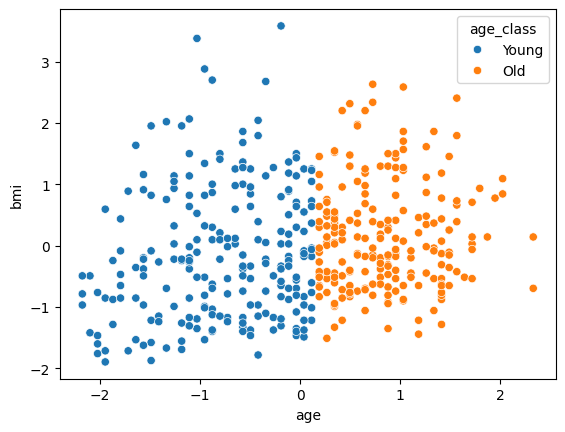

In [136]:
x_groups = df['age'].quantile([0,0.5,1])
x_class = ['Young','Old']
df['age_class'] = pd.cut(df['age'],bins=x_groups,labels=x_class)


sns.scatterplot(x=df['age'],y=df['bmi'],hue = df['age_class'])
df.groupby(['age_class','bmi_cat'])['target'].agg(['mean','std','sum'])


- h0 : old_mean_bmi = young_mean_bmi
- h1 : old_mean_bmi > young_mean_bmi

t_test:

In [137]:
old = df[df['age_class'] =='Old']['bmi']
young = df[df['age_class'] == 'Young']['bmi']

bmi_years = ttest_ind(old,young)
print(bmi_years)

TtestResult(statistic=np.float64(2.6731170101364876), pvalue=np.float64(0.007796337293350056), df=np.float64(437.0))


Old people have more bmi

Permutation:


In [138]:
observed_diff = old.mean() - young.mean()

diffs = []
random_data = np.concatenate([old,young])

for i in range (10000):
    np.random.shuffle(random_data)
    new_old = random_data[:len(old)]
    new_young = random_data[len(young):]
    diffs.append(new_old.mean() - new_young.mean())

p_value = np.mean(np.array(diffs) >= observed_diff) #unilateral test(less,equal on left)
print(f'p_value : {p_value}')

p_value : 0.0039


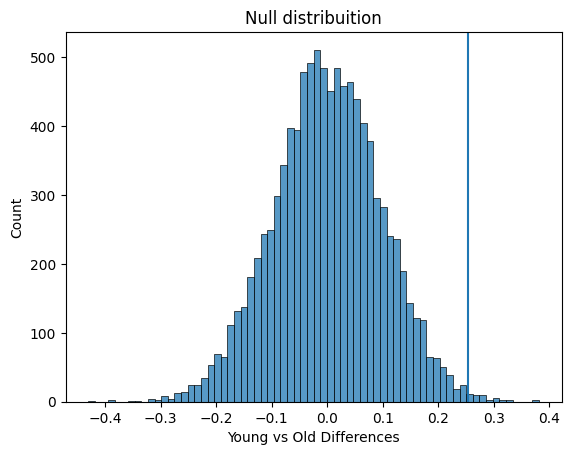

In [139]:
plt.title('Null distribuition')
sns.histplot(x=diffs)
plt.xlabel('Young vs Old Differences')
plt.axvline(observed_diff)


If we assume h0,there's 0.41% of chance of we see the real diference between old and young where : old mean > young > mean 

4. Age + Sex Affects diabetes progression?


In [140]:
x_age_sex = df[['age','sex']]
x_age_sex = sm.add_constant(x_age_sex)
y_age_sex = df['target']

model_age_sex = sm.OLS(y_age_sex,x_age_sex).fit()
print('P vals of each val + model val1-val2')
print(f' p_vals: {(model_age_sex.pvalues)} \n, f_val: {model_age_sex.fvalue}')

P vals of each val + model val1-val2
 p_vals: const    2.112595e-156
age       1.076874e-04
sex       8.215392e-01
dtype: float64 
, f_val: 8.058792462829933


In [141]:
print(f'influence in target (+1 in var = x in target): {model_age_sex.tvalues}')

influence in target (+1 in var = x in target): const    42.146691
age       3.908151
sex       0.225701
dtype: float64


In [142]:
print(model_age_sex.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     8.059
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000365
Time:                        18:49:15   Log-Likelihood:                -2539.2
No. Observations:                 442   AIC:                             5084.
Df Residuals:                     439   BIC:                             5097.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      3.610     42.147      0.0

- Just age has a significative influence in target.so sex is not necessary to predict diabetes.

5. Blood sugar level and Colesterol affects diabetes?



In [143]:
x_bp_s1 = df[['bp','s1']]
x_bp_s1 = sm.add_constant(x_bp_s1)
y_bp_s1 = df['target']

model_bp_s1 = sm.OLS(y_bp_s1,x_bp_s1).fit()
print(model_bp_s1.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     57.16
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           8.64e-23
Time:                        18:49:15   Log-Likelihood:                -2496.0
No. Observations:                 442   AIC:                             4998.
Df Residuals:                     439   BIC:                             5010.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      3.274     46.472      0.0

Both have a strong relation with target.that means that we can use them to meansure diabetes progression.

So let's compare an model with a the joined variables;

In [144]:
x_bp = df['bp']
x_bp = sm.add_constant(x_bp)
y_bp = df['target']

model_bp = sm.OLS(y_bp,x_bp).fit()

f_val,p_val,df_diff = model_bp_s1.compare_f_test(model_bp)
print(f'f_val: {f_val} \n p_val: {p_val} \n diff: {df_diff}')

f_val: 6.478861245920082 
 p_val: 0.011257522040120344 
 diff: 1.0


Before we test ML models and make predictions,let's all compare model valid hypotesis with diabetes progression:

In [145]:
x_data = df[['age','bmi','bp','s1','s2','s3','s4','s5','s6']]
x_data =sm.add_constant(x_data)
y_data = df['target']

general_diabetes_model = sm.OLS(y_data,x_data).fit()
print(general_diabetes_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     48.11
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           8.80e-60
Time:                        18:49:15   Log-Likelihood:                -2393.7
No. Observations:                 442   AIC:                             4807.
Df Residuals:                     432   BIC:                             4848.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.618     58.105      0.0

Best variables :
1. Bmi : increases diabetes progresion by 6 and has the best confidence for predict target.
2. bp : less errors and good confidence.
3. s5 : biggest influence in target (68).
- all p_values < 0.00...

with all features (unless sex),we explain 50%~ of target.would be good if we test just with these 3 features;

In [146]:
x_data_best = df[['bmi','bp','s5']]
x_data_best =sm.add_constant(x_data_best)
y_data_best = df['target']

general_diabetes_model_best = sm.OLS(y_data_best,x_data_best).fit()
print(general_diabetes_model_best.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     134.8
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           7.16e-62
Time:                        18:49:15   Log-Likelihood:                -2402.6
No. Observations:                 442   AIC:                             4813.
Df Residuals:                     438   BIC:                             4830.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.653     57.342      0.0

- f Stat : 48 > -> 138 = we removed the bias of model.there's a smaller proportion of errors now
- Prob(f-Statistic) : 8.e-60 -> 7;e-62 = probability of acase result still more small.
- Cond. No. : 7.e+03 -> 978 = less multicollinearity

adj. R-squared : 49% -> 47.7%
- This means that with all those variables we explain just 1.7% better than with just these (bp,bmi and s5)


### Machine Learning Models
Now we already know how this data works,we can manipulate it for new hypotesis in machine learning foundational models and predict diabetes progression.

In [147]:
#data:
from sklearn.model_selection import train_test_split

X = df[['bmi','bp','s5']]
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=22)

- Linear Model : assume variables linearity
- Lasso Model : Set less important features coef to zero
- Ridge Model: Good for multicolinearity
- Elastic Model : regularization between lasso and ridge

In [148]:
#Linear Regression
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet

linear_m = LinearRegression()
lasso_m = Lasso(random_state=22)
ridge_m = Ridge(solver='cholesky')
elastic_m = ElasticNet(l1_ratio=0.5)

linear_m.fit(x_train,y_train)
lasso_m.fit(x_train,y_train)
ridge_m.fit(x_train,y_train)
elastic_m.fit(x_train,y_train)


y_linear = linear_m.predict(x_test)
y_lasso = lasso_m.predict(x_test)
y_ridge = ridge_m.predict(x_test)
y_elastic = elastic_m.predict(x_test)


- Generalization;

In [149]:
#evaluations:
from sklearn.model_selection import cross_val_score

#universal test for all models

linear_score = cross_val_score(linear_m,x_train,y_train,cv=3,
                            scoring='r2')

lasso_score = cross_val_score(lasso_m,x_train,y_train,cv=3,
                            scoring='r2')

ridge_score = cross_val_score(ridge_m,x_train,y_train,cv=3,
                            scoring='r2')

elastic_score = cross_val_score(elastic_m,x_train,y_train,cv=3,
                            scoring='r2')

print(f'linear : {linear_score} \n lasso: {lasso_score} \n ridge: {ridge_score} \n elastic: {elastic_score}')

linear : [0.45322898 0.4642365  0.48140066] 
 lasso: [0.45855811 0.46179318 0.47940574] 
 ridge: [0.45382161 0.46395429 0.48144554] 
 elastic: [0.46463363 0.4224626  0.45060375]


Predicts

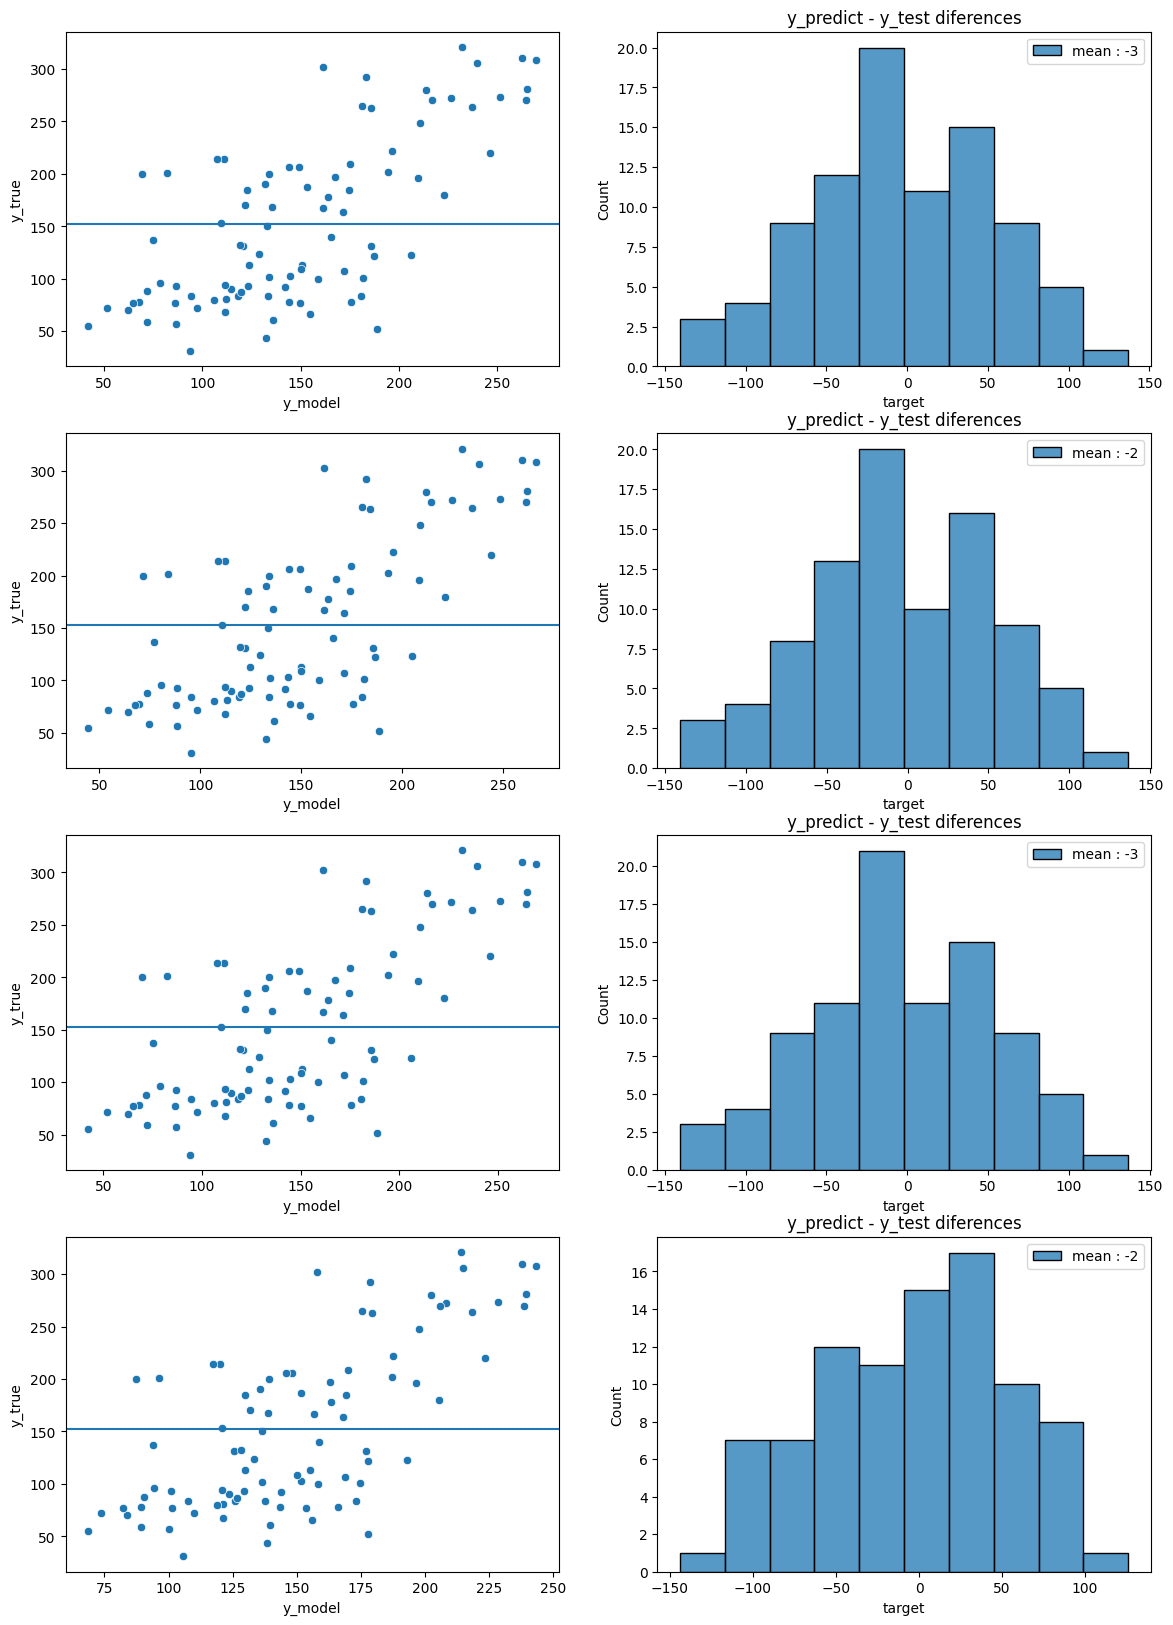

In [150]:
data = [y_linear,y_lasso,y_ridge,y_elastic]

plt.figure(figsize=(14,20))

m=1
for x in data:

    plt.subplot(4,2,m)
    sns.scatterplot(x=x,y=y_test)
    plt.axhline(y_test.mean())
    plt.xlabel('y_model')
    plt.ylabel('y_true')
    
    plt.subplot(4,2,m+1)
    sns.histplot(x=x-y_test,bins=10,label=f'mean : {int((x-y_test).mean())}')
    plt.legend()
    plt.title('y_predict - y_test diferences')

    m+=2

plt.show()

#### Evaluation

In [151]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score

print(f'''
    linear_score = rmse: {root_mean_squared_error(y_test,y_linear)},mse: {mean_squared_error(y_test,y_linear)},
    mae: {mean_absolute_error(y_test,y_linear)} \n 
lasso_score = rmse: {root_mean_squared_error(y_test,y_lasso)},mse: {mean_squared_error(y_test,y_lasso)},
    mae: {mean_absolute_error(y_test,y_lasso)} \n 
ridge_score = rmse: {root_mean_squared_error(y_test,y_ridge)},mse: {mean_squared_error(y_test,y_ridge)},
    mae: {mean_absolute_error(y_test,y_ridge)} \n 
elastic_score = rmse: {root_mean_squared_error(y_test,y_elastic)},mse: {mean_squared_error(y_test,y_elastic)},
    mae: {mean_absolute_error(y_test,y_elastic)} \n 

''')
    


    linear_score = rmse: 56.55621290198597,mse: 3198.6052178147647,
    mae: 45.85791831705691 
 
lasso_score = rmse: 56.60200668045227,mse: 3203.787160253963,
    mae: 46.00120228078581 
 
ridge_score = rmse: 56.55397265899529,mse: 3198.351823514387,
    mae: 45.86295275312436 
 
elastic_score = rmse: 57.737939916159114,mse: 3333.669705762,
    mae: 47.985049427051145 
 




Pipeline and Scalling Evaluation

In [152]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

new_data = Pipeline([
    ('poly_features',PolynomialFeatures(degree=3)),
    ('scalling',StandardScaler()),
])

new_linear = LinearRegression()
new_lasso = Lasso()
new_ridge = Ridge(solver='cholesky')
new_elastic = ElasticNet(l1_ratio=0.5)

models = [new_linear,new_lasso,new_ridge,new_elastic]

x_new_train = new_data.fit_transform(x_train)
x_new_test = new_data.transform(x_test)

def models_predicts(models):

    for model in models:
        model.fit(x_new_train,y_train)
        model_predict = model.predict(x_new_test)

        print(f'''r2: {r2_score(y_test,model_predict)},
            mae: {mean_absolute_error(y_test,model_predict)}''')

In [153]:
print(models_predicts(models))

r2: 0.445894385292371,
            mae: 45.43721800597576
r2: 0.4928198714207559,
            mae: 44.0216946681294
r2: 0.44847508070517295,
            mae: 45.31895099380751
r2: 0.49250066597296227,
            mae: 45.406214786423796
None


After a lot of tests,it sounds that Lasso is the best models through we already found the best features.

In [154]:
from sklearn.model_selection import GridSearchCV

lasso_model = Lasso()

lasso_parans = {'alpha':[1,100,1000],'positive':(True,False),
            'fit_intercept':(True,False),'selection':['cyclic','random'],'tol':[0.0001,0.001,0.01,0.1,1]}

model = GridSearchCV(lasso_model,lasso_parans,scoring='neg_root_mean_squared_error',cv=2,return_train_score=True)
model.fit(x_train,y_train)


,estimator,Lasso()
,param_grid,"{'alpha': [1, 100, ...], 'fit_intercept': (True, ...), 'positive': (True, ...), 'selection': ['cyclic', 'random'], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,1


In [155]:
print(f'''best_model: {model.best_estimator_} \n parans: {model.best_params_} \n score(rmse): {-model.best_score_} \n
    results: {model.best_index_}''')

best_model: Lasso(alpha=1, positive=True, selection='random', tol=0.01) 
 parans: {'alpha': 1, 'fit_intercept': True, 'positive': True, 'selection': 'random', 'tol': 0.01} 
 score(rmse): 55.59398210594323 

    results: 7


#### Score parans

In [156]:
model_dist_results = -model.cv_results_['mean_test_score']
print(model_dist_results.mean(),model_dist_results.std())

118.59900841192639 49.51527371562715


Text(0, 0.5, 'RMSE')

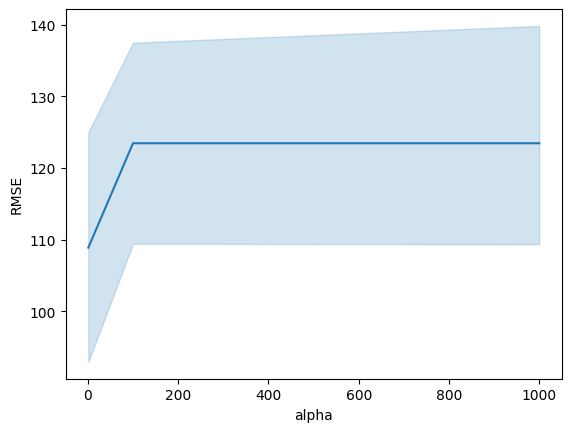

In [157]:
sns.lineplot(x=model.cv_results_['param_alpha'].data,y=-model.cv_results_['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('RMSE')


#### Features Influence

Text(0.5, 0, 'features coef')

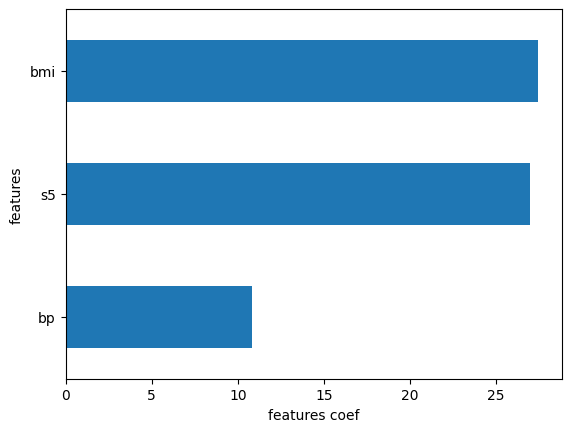

In [158]:
coef = pd.Series(model.best_estimator_.coef_,index=x_test.columns)
coef.sort_values().plot(kind='barh')

plt.ylabel('features')
plt.xlabel('features coef')



<Axes: >

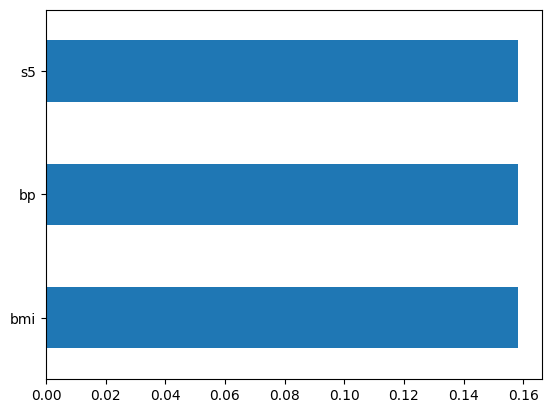

In [159]:
from sklearn.inspection import permutation_importance

feature_importances = permutation_importance(model.best_estimator_,x_test,y_test,scoring='r2')
#rmse works equal

f_imp = pd.Series(feature_importances.importances.mean(),index=x_test.columns)
f_imp.sort_values().plot(kind='barh')